# $(SA) Baseline$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Base_Line_Simple_Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
59,9,3,"(0.67, 1.4)","(-0.008, 0.921, -0.0, -0.84)",0,1.0,"(0.01, 0.731, -0.017, -0.661)",1.0,1.0,"(0.025, 0.921, -0.03, -0.844)"
1508,7,64,"(0.04, 1.5)","(0.056, 0.19, -0.054, -0.146)",1,1.0,"(0.06, 0.376, -0.056, -0.245)",1.0,1.0,"(0.067, 0.563, -0.061, -0.344)"
1682,4,71,"(0.85, 1.7)","(-0.017, 0.002, 0.02, 0.034)",1,1.0,"(-0.017, 0.192, 0.021, -0.153)",1.0,1.0,"(-0.013, 0.382, 0.018, -0.339)"
1656,22,70,"(0.22, 1.9)","(0.106, -0.345, -0.06, 0.13)",0,1.0,"(0.099, -0.53, -0.057, 0.209)",1.0,1.0,"(0.089, -0.345, -0.053, 0.12)"
1486,61,63,"(0.1, 1.6)","(0.124, -1.233, -0.176, 0.223)",1,1.0,"(0.099, -1.047, -0.172, 0.116)",0.0,1.0,"(0.078, -1.232, -0.169, 0.189)"
...,...,...,...,...,...,...,...,...,...,...
955,6,42,"(0.01, 0.2)","(-0.004, -0.445, 0.145, 1.701)",0,1.0,"(-0.013, -0.662, 0.179, 2.485)",1.0,1.0,"(-0.026, -0.455, 0.229, 1.938)"
1550,17,66,"(0.99, 1.0)","(-0.063, -0.195, 0.186, 0.735)",0,1.0,"(-0.067, -0.397, 0.2, 1.197)",0.0,1.0,"(-0.075, -0.599, 0.224, 1.66)"
219,5,9,"(0.36, 0.2)","(0.044, 0.202, -0.022, -0.889)",1,1.0,"(0.048, 0.426, -0.04, -1.813)",1.0,1.0,"(0.056, 0.65, -0.076, -2.754)"
1578,27,67,"(0.31, 1.8)","(0.153, 1.638, -0.097, -0.889)",1,1.0,"(0.186, 1.825, -0.115, -0.994)",1.0,1.0,"(0.223, 2.011, -0.134, -1.101)"


In [3]:
model = Base_Line_Simple_Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=500)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_s,transition,reward
0,0,"[0.025606714189052582, 0.8360695838928223, 0.0...",1.856421,0.757288
1,1,"[0.024867819622159004, 0.8276519775390625, 0.0...",1.841131,0.754814
2,2,"[0.024164635688066483, 0.8193374872207642, 0.0...",1.826010,0.752389
3,3,"[0.023496996611356735, 0.811125636100769, 0.06...",1.811058,0.750006
4,4,"[0.022864539176225662, 0.8030158877372742, 0.0...",1.796273,0.747658


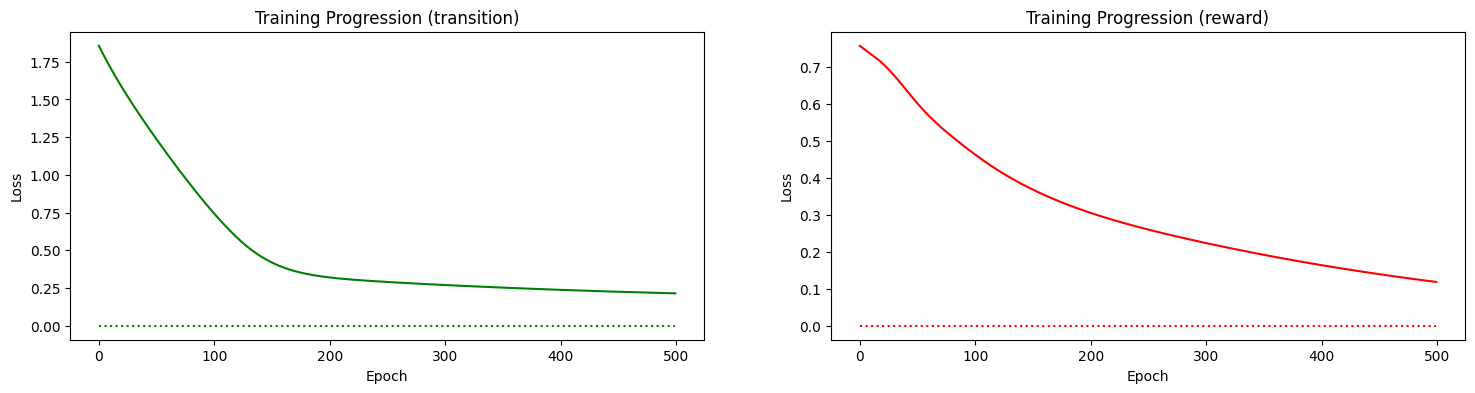

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

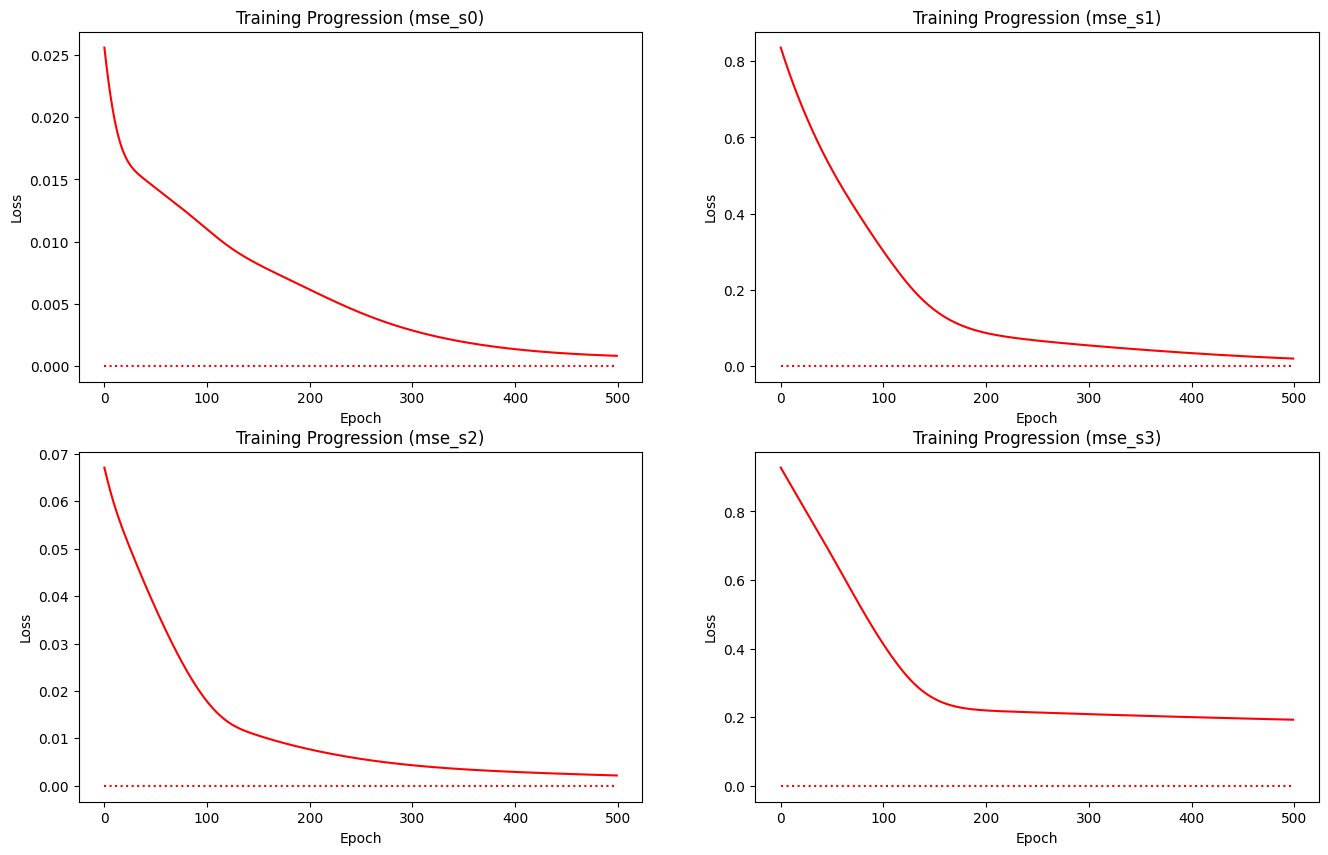

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

# Evaluation

In [ ]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,estimated_s,estimated_r
0,0,0,"(0.62, 1.2)","(-0.005, -0.042, -0.019, -0.009)",0,1.0,"(-0.006, -0.233, -0.02, 0.183)",1.0,1.0,"(-0.01, -0.042, -0.016, -0.018)","(-0.011, -0.031, 0.004, -0.089)",0.6
1,1,0,"(0.62, 1.2)","(-0.006, -0.233, -0.02, 0.183)",1,1.0,"(-0.01, -0.042, -0.016, -0.018)",1.0,1.0,"(-0.011, 0.149, -0.016, -0.218)","(-0.008, 0.157, -0.009, -0.311)",0.6
2,2,0,"(0.62, 1.2)","(-0.01, -0.042, -0.016, -0.018)",1,1.0,"(-0.011, 0.149, -0.016, -0.218)",1.0,1.0,"(-0.008, 0.34, -0.021, -0.418)","(-0.001, 0.338, -0.024, -0.53)",0.6
3,3,0,"(0.62, 1.2)","(-0.011, 0.149, -0.016, -0.218)",1,1.0,"(-0.008, 0.34, -0.021, -0.418)",1.0,1.0,"(-0.001, 0.531, -0.029, -0.619)","(0.011, 0.511, -0.04, -0.743)",0.7
4,4,0,"(0.62, 1.2)","(-0.008, 0.34, -0.021, -0.418)",1,1.0,"(-0.001, 0.531, -0.029, -0.619)",1.0,1.0,"(0.009, 0.722, -0.041, -0.822)","(0.026, 0.673, -0.057, -0.949)",0.7


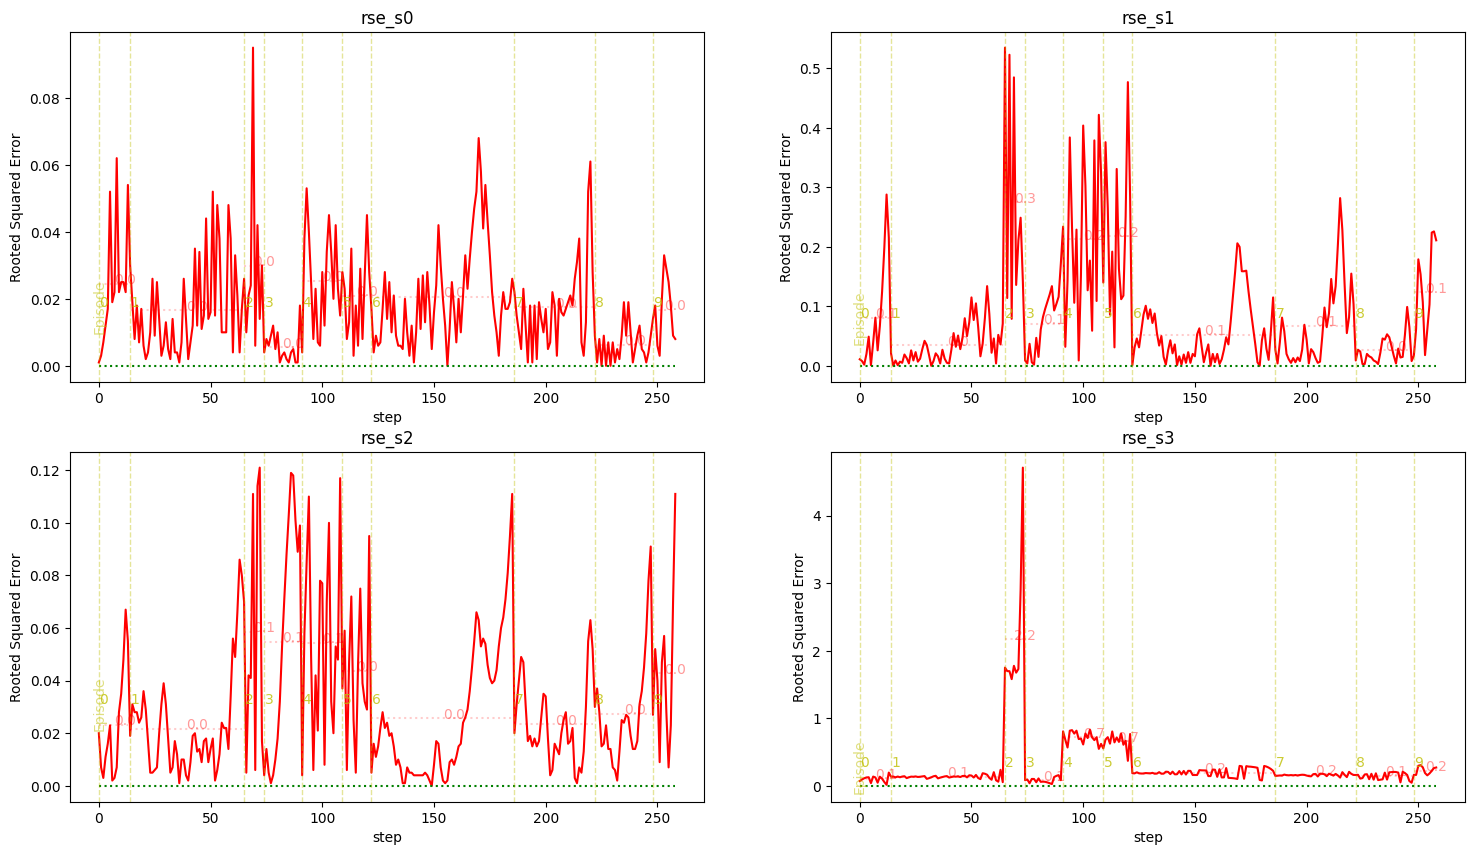

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

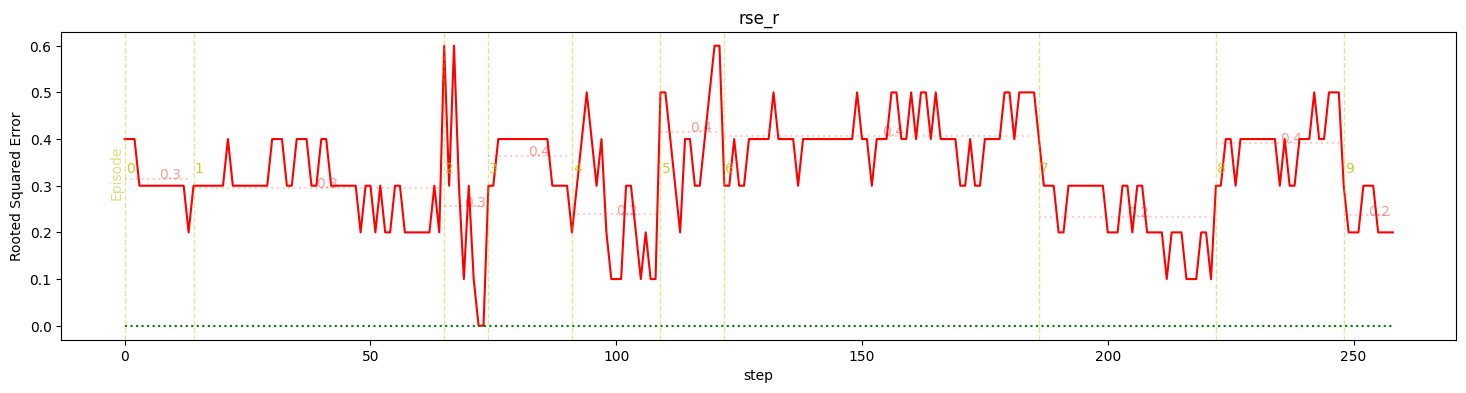

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

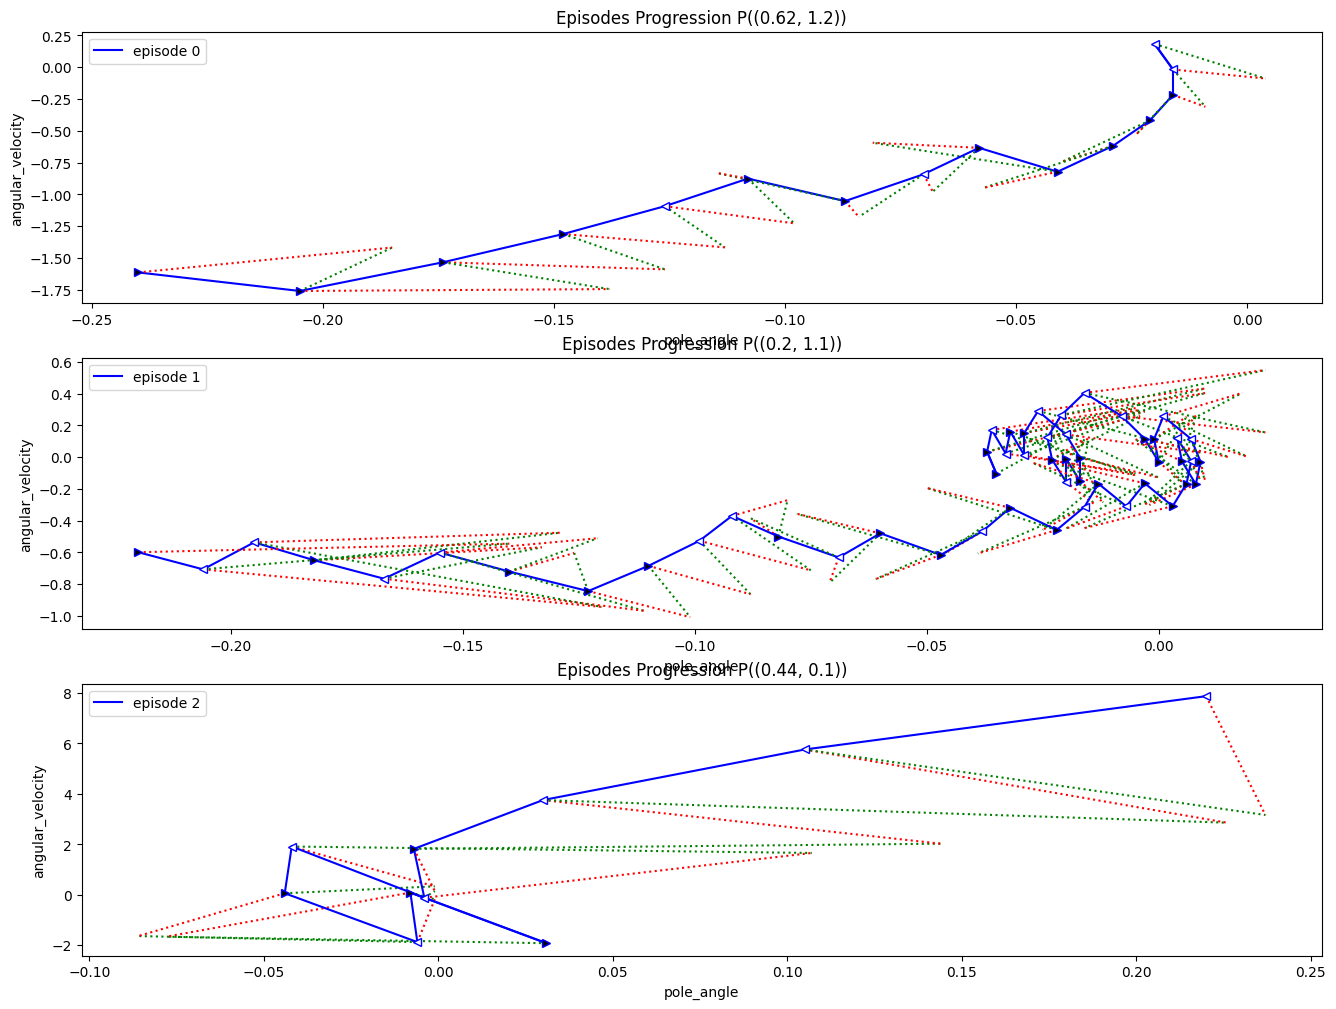

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()